In [1]:
import os

import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
#from modisco.visualization import viz_sequence
import logomaker
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import deepdish
import pyBigWig
import tqdm
import sys
import pyfaidx
import pysam
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
#from utils.data_utils import load_test_data, get_seq
#from training.utils.data_utils import get_seq, get_seq_cts

import h5py
import hdf5plugin
import shap
import glob
tf.compat.v1.disable_eager_execution()

import scipy.stats
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import pyBigWig
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
#from plotnine import *
from Bio.Seq import Seq 
from scipy.stats import pearsonr

RuntimeError: module compiled against API version 0x10 but this version of numpy is 0xf

## Functions

In [2]:
### Required functions 
def intersection(lst1, lst2):
    return list(set(lst1) & set(lst2))

In [3]:
def dna_to_one_hot(seqs):
    """
    Converts a list of DNA ("ACGT") sequences to one-hot encodings, where the
    position of 1s is ordered alphabetically by "ACGT". `seqs` must be a list
    of N strings, where every string is the same length L. Returns an N x L x 4
    NumPy array of one-hot encodings, in the same order as the input sequences.
    All bases will be converted to upper-case prior to performing the encoding.
    Any bases that are not "ACGT" will be given an encoding of all 0s.
    """
    seq_len = len(seqs[0])
    assert np.all(np.array([len(s) for s in seqs]) == seq_len)

    # Join all sequences together into one long string, all uppercase
    seq_concat = "".join(seqs).upper() + "ACGT"
    # Add one example of each base, so np.unique doesn't miss indices later

    one_hot_map = np.identity(5)[:, :-1].astype(np.int8)

    # Convert string into array of ASCII character codes;
    base_vals = np.frombuffer(bytearray(seq_concat, "utf8"), dtype=np.int8)

    # Anything that's not an A, C, G, or T gets assigned a higher code
    base_vals[~np.isin(base_vals, np.array([65, 67, 71, 84]))] = 85

    # Convert the codes into indices in [0, 4], in ascending order by code
    _, base_inds = np.unique(base_vals, return_inverse=True)

    # Get the one-hot encoding for those indices, and reshape back to separate
    return one_hot_map[base_inds[:-4]].reshape((len(seqs), seq_len, 4))

In [4]:
def softmax(x, temp=1):
    norm_x = x - np.mean(x,axis=1, keepdims=True)
    return np.exp(temp*norm_x)/np.sum(np.exp(temp*norm_x), axis=1, keepdims=True)

In [5]:
def generate_shap_dict(seqs, scores):
    print(seqs.shape, scores.shape)
    assert(seqs.shape==scores.shape)
    assert(seqs.shape[2]==4)

    # construct a dictionary for the raw shap scores and the
    # the projected shap scores
    # MODISCO workflow expects one hot sequences with shape (None,4,inputlen)
    d = {
            'raw': {'seq': np.transpose(seqs, (0, 2, 1))},
            'shap': {'seq': np.transpose(scores, (0, 2, 1))},
            'projected_shap': {'seq': np.transpose(seqs*scores, (0, 2, 1))}
        }

    return d

In [6]:
from deeplift.dinuc_shuffle import dinuc_shuffle

def combine_mult_and_diffref(mult, orig_inp, bg_data):
    to_return = []
    
    for l in [0]:
        projected_hypothetical_contribs = \
            np.zeros_like(bg_data[l]).astype("float")
        assert len(orig_inp[l].shape)==2
        
        # At each position in the input sequence, we iterate over the
        # one-hot encoding possibilities (eg: for genomic sequence, 
        # this is ACGT i.e. 1000, 0100, 0010 and 0001) and compute the
        # hypothetical difference-from-reference in each case. We then 
        # multiply the hypothetical differences-from-reference with 
        # the multipliers to get the hypothetical contributions. For 
        # each of the one-hot encoding possibilities, the hypothetical
        # contributions are then summed across the ACGT axis to 
        # estimate the total hypothetical contribution of each 
        # position. This per-position hypothetical contribution is then
        # assigned ("projected") onto whichever base was present in the
        # hypothetical sequence. The reason this is a fast estimate of
        # what the importance scores *would* look like if different 
        # bases were present in the underlying sequence is that the
        # multipliers are computed once using the original sequence, 
        # and are not computed again for each hypothetical sequence.
        for i in range(orig_inp[l].shape[-1]):
            hypothetical_input = np.zeros_like(orig_inp[l]).astype("float")
            hypothetical_input[:, i] = 1.0
            hypothetical_difference_from_reference = \
                (hypothetical_input[None, :, :] - bg_data[l])
            hypothetical_contribs = hypothetical_difference_from_reference * \
                                    mult[l]
            projected_hypothetical_contribs[:, :, i] = \
                np.sum(hypothetical_contribs, axis=-1) 
            
        to_return.append(np.mean(projected_hypothetical_contribs,axis=0))

    if len(orig_inp)>1:
        to_return.append(np.zeros_like(orig_inp[1]))
    
    return to_return


def shuffle_several_times(s):
    numshuffles=20
    if len(s)==2:
        return [np.array([dinuc_shuffle(s[0]) for i in range(numshuffles)]),
                np.array([s[1] for i in range(numshuffles)])]
    else:
        return [np.array([dinuc_shuffle(s[0]) for i in range(numshuffles)])]

In [7]:
def get_weightedsum_meannormed_logits(model):
    # Assumes the 0 task track is for profile
    # See Google slide deck for explanations
    # We meannorm as per section titled 
    # "Adjustments for Softmax Layers" in the DeepLIFT paper
    meannormed_logits = (model.outputs[0] - \
                         tf.reduce_mean(model.outputs[0], axis=1)[:, None])

    # 'stop_gradient' will prevent importance from being propagated
    # through this operation; we do this because we just want to treat
    # the post-softmax probabilities as 'weights' on the different 
    # logits, without having the network explain how the probabilities
    # themselves were derived. Could be worth contrasting explanations
    # derived with and without stop_gradient enabled...
    stopgrad_meannormed_logits = tf.stop_gradient(meannormed_logits)
    softmax_out = tf.nn.softmax(stopgrad_meannormed_logits, axis=1)
    
    # Weight the logits according to the softmax probabilities, take
    # the sum for each example. This mirrors what was done for the
    # bpnet paper.
    weightedsum_meannormed_logits = tf.reduce_sum(softmax_out * \
                                                  meannormed_logits,
                                                  axis=1)
    
    return weightedsum_meannormed_logits

In [8]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def ic_scale(pwm,background):
    odds_ratio = ((pwm+0.001)/(1.004))/(background[None,:])
    ic = ((np.log((pwm+0.001)/(1.004))/np.log(2))*pwm -\
            (np.log(background)*background/np.log(2))[None,:])
    return pwm*(np.sum(ic,axis=1)[:,None])


def plot_a(ax, base, left_edge, height, color):
    a_polygon_coords = [
        np.array([
           [0.0, 0.0],
           [0.5, 1.0],
           [0.5, 0.8],
           [0.2, 0.0],
        ]),
        np.array([
           [1.0, 0.0],
           [0.5, 1.0],
           [0.5, 0.8],
           [0.8, 0.0],
        ]),
        np.array([
           [0.225, 0.45],
           [0.775, 0.45],
           [0.85, 0.3],
           [0.15, 0.3],
        ])
    ]
    for polygon_coords in a_polygon_coords:
        ax.add_patch(matplotlib.patches.Polygon((np.array([1,height])[None,:]*polygon_coords
                                                 + np.array([left_edge,base])[None,:]),
                                                facecolor=color, edgecolor=color))


def plot_c(ax, base, left_edge, height, color):
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=1.3, height=height,
                                            facecolor=color, edgecolor=color))
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=0.7*1.3, height=0.7*height,
                                            facecolor='white', edgecolor='white'))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+1, base], width=1.0, height=height,
                                            facecolor='white', edgecolor='white', fill=True))


def plot_g(ax, base, left_edge, height, color):
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=1.3, height=height,
                                            facecolor=color, edgecolor=color))
    ax.add_patch(matplotlib.patches.Ellipse(xy=[left_edge+0.65, base+0.5*height], width=0.7*1.3, height=0.7*height,
                                            facecolor='white', edgecolor='white'))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+1, base], width=1.0, height=height,
                                            facecolor='white', edgecolor='white', fill=True))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+0.825, base+0.085*height], width=0.174, height=0.415*height,
                                            facecolor=color, edgecolor=color, fill=True))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+0.625, base+0.35*height], width=0.374, height=0.15*height,
                                            facecolor=color, edgecolor=color, fill=True))


def plot_t(ax, base, left_edge, height, color):
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge+0.4, base],
                  width=0.2, height=height, facecolor=color, edgecolor=color, fill=True))
    ax.add_patch(matplotlib.patches.Rectangle(xy=[left_edge, base+0.8*height],
                  width=1.0, height=0.2*height, facecolor=color, edgecolor=color, fill=True))

default_colors = {0:'green', 1:'blue', 2:'orange', 3:'red'}
default_plot_funcs = {0:plot_a, 1:plot_c, 2:plot_g, 3:plot_t}
def plot_weights_given_ax(ax, array,
                 height_padding_factor,
                 length_padding,
                 subticks_frequency,
                 highlight,
                 colors=default_colors,
                 plot_funcs=default_plot_funcs,
                 ylabel="",
                 ylim=None):
    if len(array.shape)==3:
        array = np.squeeze(array)
    assert len(array.shape)==2, array.shape
    if (array.shape[0]==4 and array.shape[1] != 4):
        array = array.transpose(1,0)
    assert array.shape[1]==4
    max_pos_height = 0.0
    min_neg_height = 0.0
    heights_at_positions = []
    depths_at_positions = []
    for i in range(array.shape[0]):
        #sort from smallest to highest magnitude
        acgt_vals = sorted(enumerate(array[i,:]), key=lambda x: abs(x[1]))
        positive_height_so_far = 0.0
        negative_height_so_far = 0.0
        for letter in acgt_vals:
            plot_func = plot_funcs[letter[0]]
            color=colors[letter[0]]
            if (letter[1] > 0):
                height_so_far = positive_height_so_far
                positive_height_so_far += letter[1]                
            else:
                height_so_far = negative_height_so_far
                negative_height_so_far += letter[1]
            plot_func(ax=ax, base=height_so_far, left_edge=i, height=letter[1], color=color)
        max_pos_height = max(max_pos_height, positive_height_so_far)
        min_neg_height = min(min_neg_height, negative_height_so_far)
        heights_at_positions.append(positive_height_so_far)
        depths_at_positions.append(negative_height_so_far)

    #now highlight any desired positions; the key of
    #the highlight dict should be the color
    for color in highlight:
        for start_pos, end_pos in highlight[color]:
            assert start_pos >= 0.0 and end_pos <= array.shape[0]
            min_depth = np.min(depths_at_positions[start_pos:end_pos])
            max_height = np.max(heights_at_positions[start_pos:end_pos])
            ax.add_patch(
                matplotlib.patches.Rectangle(xy=[start_pos,min_depth],
                    width=end_pos-start_pos,
                    height=max_height-min_depth,
                    edgecolor=color, fill=False))
            
    ax.set_xlim(-length_padding, array.shape[0]+length_padding)
    ax.xaxis.set_ticks(np.arange(0.0, array.shape[0]+1, subticks_frequency))

    if ylim is not None:
        # Use user-specified y-axis limits
        min_neg_height, max_pos_height = ylim
        assert min_neg_height <= 0
        assert max_pos_height >= 0

    height_padding = max(abs(min_neg_height)*(height_padding_factor),
                         abs(max_pos_height)*(height_padding_factor))
    ax.set_ylim(min_neg_height-height_padding, max_pos_height+height_padding)
    ax.set_ylabel(ylabel)
    ax.yaxis.label.set_fontsize(15)


def plot_weights(array,
                 figsize=(20,2),
                 height_padding_factor=0.2,
                 length_padding=1.0,
                 subticks_frequency=1.0,
                 colors=default_colors,
                 plot_funcs=default_plot_funcs,
                 highlight={},
                 ylabel="",
                 ylim=None,
                 title=None,
                 filename=None,
                 return_fig=False):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111) 
    plot_weights_given_ax(ax=ax, array=array,
        height_padding_factor=height_padding_factor,
        length_padding=length_padding,
        subticks_frequency=subticks_frequency,
        colors=colors,
        plot_funcs=plot_funcs,
        highlight=highlight,
        ylabel=ylabel,
        ylim=ylim)
    plt.ylim(ylim)
    plt.title(title)
    plt.savefig(filename,format="svg")

    if return_fig:
        return fig
    plt.show()

In [9]:
def calculate_correlations(array1, array2):
    correlations = np.zeros(array1.shape[0])
    
    for i in range(array1.shape[0]):
        corr, _ = pearsonr(array1[i], array2[i])
        correlations[i] = corr
    
    return correlations

In [10]:
from collections import Counter

def find_common_peaks(peaks):
    # Count occurrences of each peak
    peak_counts = Counter(peaks)

    # Filter peaks that occur at least twice
    common_peaks = [peak for peak, count in peak_counts.items() if count >= 2]

    return common_peaks


def merge_lists(lists):
    merged_list = []
    for lst in lists:
        merged_list.extend(lst)
    return merged_list

In [11]:
def generate_onehot_sequences(genome_fasta_path,peaks_with_summit):
    ref = pyfaidx.Fasta(genome_fasta_path)
    INPUT_LEN = 2114
    sequences = []
    buffer = 500
    for i,x in peaks_with_summit.iterrows():
        sequence = str(ref[x['peak_chrom']][((x['peak_start'] + x['summit']) - INPUT_LEN//2):((x['peak_start'] + x['summit']) + INPUT_LEN//2)])
        if len(sequence)==2114:
            sequence = sequence[:INPUT_LEN]
            sequences.append(sequence)
        else: 
            print(i)
    onehot_seq = []
    for i in range(len(sequences)):
        onehot_seq.append(dna_to_one_hot(sequences[i]).reshape(1,-1,4))

    onehot_seq = np.concatenate( onehot_seq, axis=0 )
    print(onehot_seq.shape)
    return sequences,onehot_seq

In [12]:
def compute_and_save_shap_profile(species_model,onehot_seq):
    model_profile_explainers = shap.explainers.deep.TFDeepExplainer(
    (species_model.input, get_weightedsum_meannormed_logits(species_model)),
    shuffle_several_times,
    combine_mult_and_diffref=combine_mult_and_diffref)
    profile_shap_scores = np.array(model_profile_explainers.shap_values(
    onehot_seq, progress_message=200))
    profile_shap_scores_dict = generate_shap_dict(onehot_seq, profile_shap_scores)
    return profile_shap_scores_dict

In [13]:
def compute_and_save_shap_scores(species_model,onehot_seq):
    model_profile_explainers = shap.explainers.deep.TFDeepExplainer(
    (species_model.input, get_weightedsum_meannormed_logits(species_model)),
    shuffle_several_times,
    combine_mult_and_diffref=combine_mult_and_diffref)
    profile_shap_scores = np.array(model_profile_explainers.shap_values(
    onehot_seq, progress_message=200))
    profile_shap_scores_dict = generate_shap_dict(onehot_seq, profile_shap_scores)
    profile_shap_scores_dict = profile_shap_scores_dict['projected_shap']['seq'][:]
    profile_shap_scores_dict = profile_shap_scores_dict.transpose(0,2,1)
    profile_shap_scores_dict = np.sum(profile_shap_scores_dict,axis=2)
    return profile_shap_scores_dict

In [14]:
def compute_and_save_shap_count(species_model,onehot_seq):
    profile_model_counts_explainer = shap.explainers.deep.TFDeepExplainer(
    (species_model.input, tf.reduce_sum(species_model.outputs[1], axis=-1)),
    shuffle_several_times,
    combine_mult_and_diffref=combine_mult_and_diffref)
    counts_shap_scores = np.array(profile_model_counts_explainer.shap_values(
    onehot_seq, progress_message=100))
    print(counts_shap_scores.shape)
    counts_scores_dict = generate_shap_dict(onehot_seq, counts_shap_scores)
    counts_shap_scores = np.multiply(onehot_seq,counts_shap_scores)
    return counts_scores_dict

In [15]:
def min_max_normalize_rows(df):
    # Copy the original DataFrame to avoid modifying the original data
    normalized_df = df.copy()
    
    # Iterate over each row
    for index, row in df.iterrows():
        # Calculate min and max values for the row
        min_value = row.min()
        max_value = row.max()
        
        # Perform min-max normalization for the row
        normalized_row = (row - min_value) / (max_value - min_value)
        
        # Update the normalized row in the new DataFrame
        normalized_df.loc[index] = normalized_row
    
    return normalized_df

In [16]:
# zero = peakStartCoord + summitOffset - 1057
# # For positive strand
# ovStart = peakStartCoord + alignStartDelta
# # For the reverse complement ones, coordinates are given relative to the END of the peak
# ovStart = peakEndCoord + 1 - alignEndDelta
def update_align_coords(df, window_size=2114):
    # Compute zero position = start of the 2114-bp SHAP window centered at summit
    df['zero'] = df['peak_start'] +1 + df['summit'] - (window_size // 2)

    # Compute absolute start of alignment depending on strand
    df['abs_ovStart'] = df.apply(
        lambda row: (
            row['peak_start'] + row['align_start']  # positive strand
            if row['strand'] == '+'
            else row['peak_end'] + 1 - row['align_end']  # negative strand
        ), axis=1
    )

    # Compute new relative alignment positions within the SHAP window
    df['new_align_start'] = df['abs_ovStart'] - df['zero']
    df['new_align_end'] = df['new_align_start'] + df['length']

    return df

In [17]:
from scipy.stats import pearsonr
import numpy as np

def calculate_correlations_subset(array1, array2, peaks_df):
    correlations = np.full(array1.shape[0], np.nan)

    for i in range(array1.shape[0]):
        start = int(peaks_df.iloc[i]["new_align_start"])
        end = int(peaks_df.iloc[i]["new_align_end"])

        start = max(0, start)
        end = min(array1.shape[1], end)

        if end <= start:
            continue

        x = array1[i, start:end]
        y = array2[i, start:end]

        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < 2:
            continue

        if np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
            continue

        correlations[i] = pearsonr(x[mask], y[mask])[0]

    return correlations

In [77]:
# Let's now load the two models and run the difference
with tf.keras.utils.CustomObjectScope({'multinomial_null':multinomial_nll, 'tf':tf}):
    mouse_neural = keras.models.load_model("../../mouse_zebrafish/mouse/models/allneural/fold_0/models/allneural_chrombpnet_nobias.h5")
    mouse_forebrain = keras.models.load_model("../../mouse_zebrafish/mouse/models/forebrain/fold_0/models/chrombpnet_nobias.h5")
    mouse_hindbrain = keras.models.load_model("../../mouse_zebrafish/mouse/models/hindbrain/fold_0/models/chrombpnet_nobias.h5")
    mouse_spinal = keras.models.load_model("../../mouse_zebrafish/mouse/models/spinal_cord/fold_0/models/chrombpnet_nobias.h5")
    
    zebra_neural = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/allneural/fold_0_1/models/all_neural_chrombpnet_nobias.h5")
    zebra_forebrain = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/forebrain/fold_0/models/chrombpnet_nobias.h5")
    zebra_hindbrain = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/hindbrain/fold_0/models/chrombpnet_nobias.h5")
    zebra_spinal = keras.models.load_model("../../mouse_zebrafish/zebrafish/model/spinal_cord/fold_0/models/chrombpnet_nobias.h5")


In [19]:
lastz_result = pd.read_csv("./plots/zebra_mouse_conserved_peakset.tsv",sep="\t")

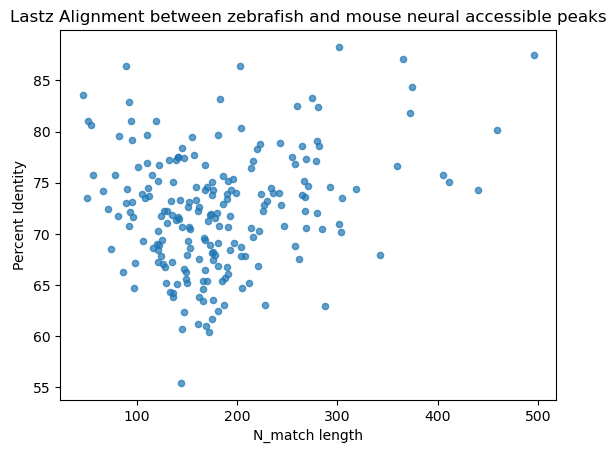

In [20]:
plt.scatter(lastz_result['n_match'], lastz_result['percent'], s=20, alpha=0.7)
plt.xlabel('N_match length')
plt.ylabel('Percent Identity')
plt.title('Lastz Alignment between zebrafish and mouse neural accessible peaks')
plt.show()

In [21]:
lastz_result = lastz_result[lastz_result.n_match >= 90]

In [22]:
lastz_result = lastz_result.reset_index(drop=True)

In [23]:
# Let's start with mouse peaks
mouse_bed = lastz_result['mouse_chr'].str.split('__', expand=True)
mouse_bed.columns = ['chrom', 'start', 'end']

# Ensure numeric and adjust start for BED 0-based format
mouse_bed['start'] = mouse_bed['start'].astype(int) - 1  # BED start
mouse_bed['end'] = mouse_bed['end'].astype(int)

# Add mouse_start, mouse_end, strand from original DataFrame
mouse_bed['mouse_start'] = lastz_result['mouse_start']
mouse_bed['mouse_end'] = lastz_result['mouse_end']
mouse_bed['mouse_strand'] = lastz_result['mouse_strand']
mouse_bed['mouse_length'] = lastz_result['mouse_length'] 
mouse_bed['percent'] = lastz_result['percent']

# Reorder columns to match desired output
mouse_final_peaks = mouse_bed[['chrom', 'start', 'end', 'mouse_start', 'mouse_end', 'mouse_strand','mouse_length','percent']]
mouse_final_peaks.columns = ['peak_chrom','peak_start','peak_end','align_start','align_end','strand','length','percent']
mouse_final_peaks['summit'] = 300
mouse_final_peaks['peak_start'] = mouse_final_peaks['peak_start'] + 1 
mouse_final_peaks = mouse_final_peaks.loc[mouse_final_peaks.groupby(['peak_chrom', 'peak_start', 'peak_end'])['percent'].idxmax()]
mouse_final_peaks = mouse_final_peaks.reset_index(drop=True)

In [24]:
# mouse final peaks table -- load from here as it has jaccard similarity 
mouse_final_peaks = pd.read_csv("../../mouse_zebrafish/cross_species/mouse_lastz_final_filtered.tsv",sep="\t")
mouse_final_peaks

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,jaccard_similarity
0,chr1,16294752,16295352,208,442,+,235,73.1,300,chr1:16294752-16295352,0.148148
1,chr1,78167780,78168380,57,436,+,380,72.2,300,chr1:78167780-78168380,0.196078
2,chr1,78171577,78172177,117,442,+,326,74.5,300,chr1:78171577-78172177,0.208333
3,chr1,120912031,120912631,131,455,+,325,67.8,300,chr1:120912031-120912631,0.188679
4,chr1,121577357,121577957,2,214,+,213,63.8,300,chr1:121577357-121577957,0.214286
...,...,...,...,...,...,...,...,...,...,...,...
147,chr8,126666190,126666790,171,586,+,416,72.0,300,chr8:126666190-126666790,0.307692
148,chr9,32685630,32686230,198,330,+,133,76.5,300,chr9:32685630-32686230,0.210526
149,chr9,61070754,61071354,19,194,+,176,72.2,300,chr9:61070754-61071354,0.173913
150,chr9,61468465,61469065,98,228,+,131,70.8,300,chr9:61468465-61469065,0.307692


In [25]:
# peak to highlight: chr1_190128561_190129161, chr1_186922679_186923279, chr14_34453645_34454245, chr14_122279384_122279984
#mouse_peak_highlight = [("chr1",190128561,190129161),("chr1",186922679,186923279),("chr14",34453645,34454245), ("chr14",122279384,122279984)]
mouse_peak_highlight = [("chr14",34453645,34454245),("chr7",49698926,49699526),("chr5",101523878,101524478)]
mask = mouse_final_peaks.apply(lambda row: (row['peak_chrom'], row['peak_start'], row['peak_end']) in mouse_peak_highlight, axis=1)
highlight_df = mouse_final_peaks[mask]


In [26]:
highlight_df

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,jaccard_similarity
48,chr14,34453645,34454245,216,336,+,121,74.4,300,chr14:34453645-34454245,0.304348
117,chr5,101523878,101524478,127,516,+,390,79.1,300,chr5:101523878-101524478,0.413793
133,chr7,49698926,49699526,102,442,+,341,82.4,300,chr7:49698926-49699526,0.254902


In [27]:
mouse_seq, mouse_finalpeaks_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_final_peaks)

(152, 2114, 4)


In [28]:
mouse_pred = mouse_neural.predict(mouse_finalpeaks_onehot_seq)
zebra_pred = zebra_neural.predict(mouse_finalpeaks_onehot_seq)

/opt/conda/lib/python3.9/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2026-03-10 21:44:02.834043: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8100


In [29]:
mouse_logits, mouse_counts = mouse_pred
zebra_logits, zebra_counts = zebra_pred

In [30]:
mouse_probs = softmax(mouse_logits)
zebra_probs = softmax(zebra_logits)

In [31]:
mouse_SHAP_profile = compute_and_save_shap_scores(mouse_neural, mouse_finalpeaks_onehot_seq)
zebra_SHAP_profile = compute_and_save_shap_scores(zebra_neural, mouse_finalpeaks_onehot_seq)


Done 0 examples of 152
(152, 2114, 4) (152, 2114, 4)
Done 0 examples of 152
(152, 2114, 4) (152, 2114, 4)


In [32]:
mouse_final_peaks

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,jaccard_similarity
0,chr1,16294752,16295352,208,442,+,235,73.1,300,chr1:16294752-16295352,0.148148
1,chr1,78167780,78168380,57,436,+,380,72.2,300,chr1:78167780-78168380,0.196078
2,chr1,78171577,78172177,117,442,+,326,74.5,300,chr1:78171577-78172177,0.208333
3,chr1,120912031,120912631,131,455,+,325,67.8,300,chr1:120912031-120912631,0.188679
4,chr1,121577357,121577957,2,214,+,213,63.8,300,chr1:121577357-121577957,0.214286
...,...,...,...,...,...,...,...,...,...,...,...
147,chr8,126666190,126666790,171,586,+,416,72.0,300,chr8:126666190-126666790,0.307692
148,chr9,32685630,32686230,198,330,+,133,76.5,300,chr9:32685630-32686230,0.210526
149,chr9,61070754,61071354,19,194,+,176,72.2,300,chr9:61070754-61071354,0.173913
150,chr9,61468465,61469065,98,228,+,131,70.8,300,chr9:61468465-61469065,0.307692


In [33]:
mouse_final_peaks = update_align_coords(mouse_final_peaks)


In [34]:
mouse_final_peaks

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,jaccard_similarity,zero,abs_ovStart,new_align_start,new_align_end
0,chr1,16294752,16295352,208,442,+,235,73.1,300,chr1:16294752-16295352,0.148148,16293996,16294960,964,1199
1,chr1,78167780,78168380,57,436,+,380,72.2,300,chr1:78167780-78168380,0.196078,78167024,78167837,813,1193
2,chr1,78171577,78172177,117,442,+,326,74.5,300,chr1:78171577-78172177,0.208333,78170821,78171694,873,1199
3,chr1,120912031,120912631,131,455,+,325,67.8,300,chr1:120912031-120912631,0.188679,120911275,120912162,887,1212
4,chr1,121577357,121577957,2,214,+,213,63.8,300,chr1:121577357-121577957,0.214286,121576601,121577359,758,971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,chr8,126666190,126666790,171,586,+,416,72.0,300,chr8:126666190-126666790,0.307692,126665434,126666361,927,1343
148,chr9,32685630,32686230,198,330,+,133,76.5,300,chr9:32685630-32686230,0.210526,32684874,32685828,954,1087
149,chr9,61070754,61071354,19,194,+,176,72.2,300,chr9:61070754-61071354,0.173913,61069998,61070773,775,951
150,chr9,61468465,61469065,98,228,+,131,70.8,300,chr9:61468465-61469065,0.307692,61467709,61468563,854,985


In [35]:
mouse_final_peaks["corr_SHAP_subset"] = calculate_correlations_subset(mouse_SHAP_profile, zebra_SHAP_profile, mouse_final_peaks)

In [36]:
mouse_final_peaks

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,jaccard_similarity,zero,abs_ovStart,new_align_start,new_align_end,corr_SHAP_subset
0,chr1,16294752,16295352,208,442,+,235,73.1,300,chr1:16294752-16295352,0.148148,16293996,16294960,964,1199,0.356193
1,chr1,78167780,78168380,57,436,+,380,72.2,300,chr1:78167780-78168380,0.196078,78167024,78167837,813,1193,0.548944
2,chr1,78171577,78172177,117,442,+,326,74.5,300,chr1:78171577-78172177,0.208333,78170821,78171694,873,1199,0.056563
3,chr1,120912031,120912631,131,455,+,325,67.8,300,chr1:120912031-120912631,0.188679,120911275,120912162,887,1212,0.279538
4,chr1,121577357,121577957,2,214,+,213,63.8,300,chr1:121577357-121577957,0.214286,121576601,121577359,758,971,0.518036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,chr8,126666190,126666790,171,586,+,416,72.0,300,chr8:126666190-126666790,0.307692,126665434,126666361,927,1343,0.487966
148,chr9,32685630,32686230,198,330,+,133,76.5,300,chr9:32685630-32686230,0.210526,32684874,32685828,954,1087,0.625221
149,chr9,61070754,61071354,19,194,+,176,72.2,300,chr9:61070754-61071354,0.173913,61069998,61070773,775,951,0.533411
150,chr9,61468465,61469065,98,228,+,131,70.8,300,chr9:61468465-61469065,0.307692,61467709,61468563,854,985,0.255040


In [37]:
corr_profile = calculate_correlations(mouse_probs, zebra_probs)
corr_SHAP_profile = mouse_final_peaks["corr_SHAP_subset"]

corr_df_mouse = {'corr_profile': corr_profile,
           'corr_SHAP_profile': corr_SHAP_profile,
           'percent' : mouse_final_peaks.percent,
           'jaccard': mouse_final_peaks.jaccard_similarity}
corr_df_mouse = pd.DataFrame(corr_df_mouse)

In [72]:
def plot_two_scatter_horizontal(df, highlight_indices=[48,117, 133]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    y_cols = ['corr_profile', 'corr_SHAP_profile']
    titles = ['Profile vs percent', 'SHAP vs percent']

    highlight_df = df.loc[highlight_indices]

    for ax, y_col, title in zip(axes, y_cols, titles):
        # Plot all points
        ax.scatter(df['percent'], df[y_col], alpha=0.7, label='All')

        # Highlight specific indices
        ax.scatter(highlight_df['percent'], highlight_df[y_col],
                   color='red', s=30, edgecolors='black', zorder=5, label='Highlighted')

        ax.set_title(title)
        ax.set_xlabel("Percent")
        ax.set_ylabel("Correlation")
        ax.grid(True)
    fig.text(0.0001, 0.5, 'Mouse', va='center', ha='center', rotation='vertical', fontsize=12)

    plt.tight_layout()
    plt.savefig("mousepeaks_SHAP_updated.svg")
    plt.show()

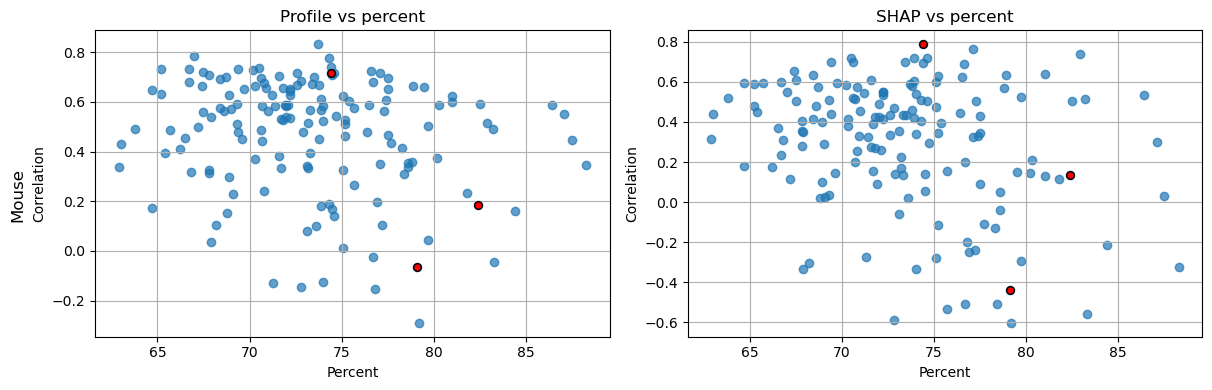

In [73]:
plot_two_scatter_horizontal(corr_df_mouse)


In [40]:
corr_df_mouse.to_csv("../../mouse_zebrafish/cross_species/intronic_mousepeaks_corr_percentsimiliarity_subsetSHAP.csv", sep="\t",index=False) # change the path 

In [48]:
# Let's start with mouse peaks
zebrafish_bed = lastz_result['zebrafish_chr'].str.split('__', expand=True)
zebrafish_bed.columns = ['chrom', 'start', 'end']

# Ensure numeric and adjust start for BED 0-based format
zebrafish_bed['start'] = zebrafish_bed['start'].astype(int) - 1  # BED start
zebrafish_bed['end'] = zebrafish_bed['end'].astype(int)

# Add mouse_start, mouse_end, strand from original DataFrame
zebrafish_bed['chrom'] = zebrafish_bed['chrom'] + '.7'

zebrafish_bed['zebrafish_start'] = lastz_result['zebrafish_start']
zebrafish_bed['zebrafish_end'] = lastz_result['zebrafish_end']
zebrafish_bed['zebrafish_strand'] = lastz_result['zebrafish_strand']
zebrafish_bed['zebrafish_length'] = lastz_result['zebrafish_length'] 
zebrafish_bed['percent'] = lastz_result['percent']

# Reorder columns to match desired output
zebrafish_final_peaks = zebrafish_bed[['chrom', 'start', 'end', 'zebrafish_start', 'zebrafish_end', 'zebrafish_strand','zebrafish_length','percent']]
zebrafish_final_peaks.columns = ['peak_chrom','peak_start','peak_end','align_start','align_end','strand','length','percent']
zebrafish_final_peaks['summit'] = 300
zebrafish_final_peaks['peak_start'] = zebrafish_final_peaks['peak_start'] + 1 
zebrafish_final_peaks = zebrafish_final_peaks.loc[zebrafish_final_peaks.groupby(['peak_chrom', 'peak_start', 'peak_end'])['percent'].idxmax()]
zebrafish_final_peaks = zebrafish_final_peaks.reset_index(drop=True)

In [51]:
zebrafish_final_peaks = pd.read_csv("../../mouse_zebrafish/cross_species/zebrafish_lastz_final_filtered.tsv",sep="\t")
zebrafish_final_peaks

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,zebrafish_chr,jaccard_similarity
0,NC_007112.7,7763429,7764360,379,704,+,326,67.8,300,NC_007112.7:7763429-7764360,NC_007112.7:7763429-7764360,0.188679
1,NC_007113.7,10362633,10363487,110,350,-,241,69.3,300,NC_007113.7:10362633-10363487,NC_007113.7:10362633-10363487,0.263158
2,NC_007113.7,18816189,18817252,688,825,+,138,79.7,300,NC_007113.7:18816189-18817252,NC_007113.7:18816189-18817252,0.205882
3,NC_007113.7,33094277,33094816,71,385,-,315,74.0,300,NC_007113.7:33094277-33094816,NC_007113.7:33094277-33094816,0.243243
4,NC_007113.7,47417933,47418535,124,576,+,453,72.2,300,NC_007113.7:47417933-47418535,NC_007113.7:47417933-47418535,0.196078
...,...,...,...,...,...,...,...,...,...,...,...,...
128,NC_007136.7,14796553,14797432,557,750,-,194,71.0,300,NC_007136.7:14796553-14797432,NC_007136.7:14796553-14797432,0.142857
129,NC_007136.7,14982500,14983144,73,334,-,262,73.4,300,NC_007136.7:14982500-14983144,NC_007136.7:14982500-14983144,0.129032
130,NC_007136.7,14993542,14994446,2,351,-,350,72.2,300,NC_007136.7:14993542-14994446,NC_007136.7:14993542-14994446,0.128205
131,NC_007136.7,14994767,14995578,3,493,-,491,81.8,300,NC_007136.7:14994767-14995578,NC_007136.7:14994767-14995578,0.310345


In [59]:
zebra_peak_highlight = [("NC_007124.7",22598758,22599234),("NC_007136.7",14461553,14462635),("NC_007132.7",19131881,19132571)]
mask = zebrafish_final_peaks.apply(lambda row: (row['peak_chrom'], row['peak_start'], row['peak_end']) in zebra_peak_highlight, axis=1)
highlight_df = zebrafish_final_peaks[mask]

In [60]:
highlight_df

,peak_chrom,peak_start,peak_end,align_start,align_end,strand,length,percent,summit,mouse_chr,zebrafish_chr,jaccard_similarity
67,NC_007124.7,22598758,22599234,132,253,-,122,74.4,300,NC_007124.7:22598758-22599234,NC_007124.7:22598758-22599234,0.304348
109,NC_007132.7,19131881,19132571,92,450,-,359,79.1,300,NC_007132.7:19131881-19132571,NC_007132.7:19131881-19132571,0.413793
127,NC_007136.7,14461553,14462635,37,382,-,346,82.4,300,NC_007136.7:14461553-14462635,NC_007136.7:14461553-14462635,0.254902


In [61]:
zebrafish_seq, zebrafish_finalpeaks_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebrafish_final_peaks)

(133, 2114, 4)


In [62]:
mouse_pred_zpeak = mouse_neural.predict(zebrafish_finalpeaks_onehot_seq)
zebra_pred_zpeak = zebra_neural.predict(zebrafish_finalpeaks_onehot_seq)

In [63]:
mouse_logits_zpeak, mouse_counts_zpeak = mouse_pred_zpeak
zebra_logits_zpeak, zebra_counts_zpeak = zebra_pred_zpeak

In [64]:
mouse_probs_zpeak = softmax(mouse_logits_zpeak)
zebra_probs_zpeak = softmax(zebra_logits_zpeak)

In [65]:
mouse_SHAP_profile_zpeak = compute_and_save_shap_scores(mouse_neural, zebrafish_finalpeaks_onehot_seq)
zebra_SHAP_profile_zpeak = compute_and_save_shap_scores(zebra_neural, zebrafish_finalpeaks_onehot_seq)

Done 0 examples of 133
(133, 2114, 4) (133, 2114, 4)
Done 0 examples of 133
(133, 2114, 4) (133, 2114, 4)


In [66]:
zebrafish_final_peaks = update_align_coords(zebrafish_final_peaks)


In [67]:
corr_profile_zpeak = calculate_correlations(zebra_probs_zpeak, mouse_probs_zpeak)
corr_SHAP_profile_zpeak = calculate_correlations_subset(zebra_SHAP_profile_zpeak, mouse_SHAP_profile_zpeak, zebrafish_final_peaks)

In [68]:
corr_df_zpeak = {'corr_profile': corr_profile_zpeak,
           'corr_SHAP_profile': corr_SHAP_profile_zpeak,
           'percent' : zebrafish_final_peaks.percent,
            'jaccard': zebrafish_final_peaks.jaccard_similarity}
corr_df_zpeak = pd.DataFrame(corr_df_zpeak)

In [74]:
def plot_two_scatter_horizontal(df, highlight_indices=[67, 109,127]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    y_cols = ['corr_profile', 'corr_SHAP_profile']
    titles = ['Profile vs percent', 'SHAP vs percent']

    highlight_df = df.loc[highlight_indices]

    for ax, y_col, title in zip(axes, y_cols, titles):
        # Plot all points
        ax.scatter(df['percent'], df[y_col], alpha=0.7, label='All')

        # Highlight specific indices
        ax.scatter(highlight_df['percent'], highlight_df[y_col],
                   color='red', s=30, edgecolors='black', zorder=5, label='Highlighted')

        ax.set_title(title)
        ax.set_xlabel("Percent")
        ax.set_ylabel("Correlation")
        ax.grid(True)
    fig.text(0.0001, 0.5, 'Zebrafish-peaks', va='center', ha='center', rotation='vertical', fontsize=12)

    plt.tight_layout()
    plt.savefig("zebrapeaks_SHAP_updated.svg")
    plt.show()

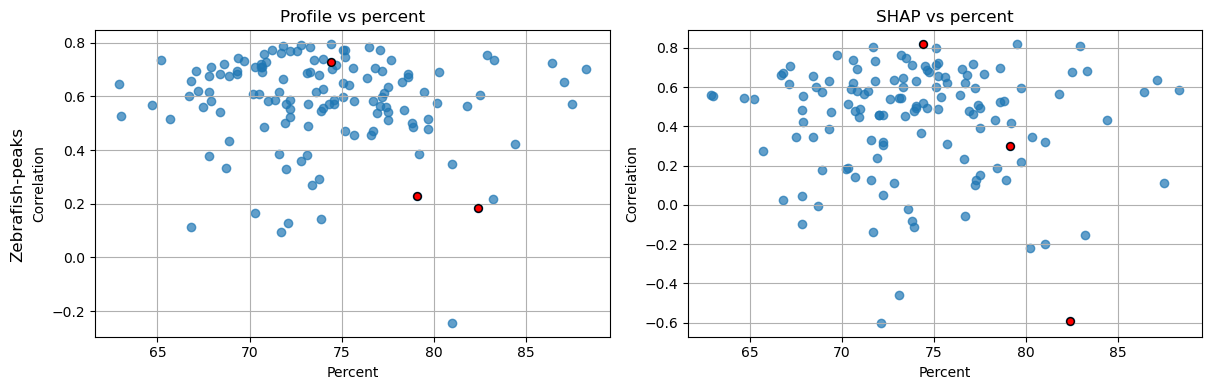

In [75]:
plot_two_scatter_horizontal(corr_df_zpeak)


In [71]:
corr_df_zpeak.to_csv("../../mouse_zebrafish/cross_species/intronic_zebrapeaks_corr_percentsimiliarity_subsetSHAP.csv", sep="\t",index=False) # change the path 

### Region specific code 

### Mouse

In [78]:
#### Mouse forebrain/midbrain
mouse_forebrain_peaks = ['chr19:59466914-59467514',
                   'chr2:105719613-105720213',
                   'chr11:22034407-22035007',
                   'chr6:144681224-144681824',
                   'chr13:98572430-98573030',
                   'chr5:139585152-139585752',
                   'chr19:59717761-59718361',
                   'chr2:105720702-105721302',
                   'chr2:105719613-105720213',
                   'chr8:126666190-126666790',
                   'chr10:42613855-42614455',
                   'chr2:146262081-146262681',
                   'chr6:138672532-138673132',
                   'chr14:48750835-48751435',
                   'chr17:85488338-85488938',
                   'chr1:139000493-139001093']

mouse_hindbrain_peaks = ['chr1:16294752-16295352', 
                         'chr10:19448759-19449359']

mouse_spinal_peaks = ['chr2:169832081-169832681',
                      'chr14:22268565-22269165',
                      'chr5:75012773-75013373',
                      'chr2:115868965-115869565',
                      'chr2:74734326-74734926',
                      'chr9:61070754-61071354',
                      'chr2:74730121-74730721',
                      'chr2:166030948-166031548',
                      'chr6:99467026-99467626',
                      'chr1:120912031-120912631']

In [82]:
mouse_forebrain_df = mouse_final_peaks[mouse_final_peaks.mouse_chr.isin(mouse_forebrain_peaks)]
mouse_hindbrain_df = mouse_final_peaks[mouse_final_peaks.mouse_chr.isin(mouse_hindbrain_peaks)]
mouse_spinal_df = mouse_final_peaks[mouse_final_peaks.mouse_chr.isin(mouse_spinal_peaks)]

In [83]:
mouse_forebrain_seq, mouse_forebrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_forebrain_df)
mouse_hindbrain_seq, mouse_hindbrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_hindbrain_df)
mouse_spinal_seq, mouse_spinal_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/mouse/models/mm10.genome.fa',mouse_spinal_df)

(15, 2114, 4)
(2, 2114, 4)
(10, 2114, 4)


In [102]:
# forebrain 
mouse_fbpeak_mouse_fbmodel_SHAP = compute_and_save_shap_scores(mouse_forebrain, mouse_forebrain_onehot_seq)
mouse_fbpeak_zebra_fbmodel_SHAP = compute_and_save_shap_scores(zebra_forebrain, mouse_forebrain_onehot_seq)
mouse_fbpeak_zebra_hbmodel_SHAP = compute_and_save_shap_scores(zebra_hindbrain, mouse_forebrain_onehot_seq)
mouse_fbpeak_zebra_spmodel_SHAP = compute_and_save_shap_scores(zebra_spinal, mouse_forebrain_onehot_seq)

# hindbrain 
mouse_hbpeak_mouse_hbmodel_SHAP = compute_and_save_shap_scores(mouse_hindbrain, mouse_hindbrain_onehot_seq)
mouse_hbpeak_zebra_fbmodel_SHAP = compute_and_save_shap_scores(zebra_forebrain, mouse_hindbrain_onehot_seq)
mouse_hbpeak_zebra_hbmodel_SHAP = compute_and_save_shap_scores(zebra_hindbrain, mouse_hindbrain_onehot_seq)
mouse_hbpeak_zebra_spmodel_SHAP = compute_and_save_shap_scores(zebra_spinal, mouse_hindbrain_onehot_seq)

# spinal cord 
mouse_sppeak_mouse_spmodel_SHAP = compute_and_save_shap_scores(mouse_spinal, mouse_spinal_onehot_seq)
mouse_sppeak_zebra_fbmodel_SHAP = compute_and_save_shap_scores(zebra_forebrain, mouse_spinal_onehot_seq)
mouse_sppeak_zebra_hbmodel_SHAP = compute_and_save_shap_scores(zebra_hindbrain, mouse_spinal_onehot_seq)
mouse_sppeak_zebra_spmodel_SHAP = compute_and_save_shap_scores(zebra_spinal, mouse_spinal_onehot_seq)


Done 0 examples of 15
(15, 2114, 4) (15, 2114, 4)
Done 0 examples of 15
(15, 2114, 4) (15, 2114, 4)
Done 0 examples of 15
(15, 2114, 4) (15, 2114, 4)
Done 0 examples of 15
(15, 2114, 4) (15, 2114, 4)
Done 0 examples of 2
(2, 2114, 4) (2, 2114, 4)
Done 0 examples of 2
(2, 2114, 4) (2, 2114, 4)
Done 0 examples of 2
(2, 2114, 4) (2, 2114, 4)
Done 0 examples of 2
(2, 2114, 4) (2, 2114, 4)
Done 0 examples of 10
(10, 2114, 4) (10, 2114, 4)
Done 0 examples of 10
(10, 2114, 4) (10, 2114, 4)
Done 0 examples of 10
(10, 2114, 4) (10, 2114, 4)
Done 0 examples of 10
(10, 2114, 4) (10, 2114, 4)


In [103]:
# forebrain
mouse_fbpeak_zebra_fb_SHAP_corr = calculate_correlations_subset(mouse_fbpeak_mouse_fbmodel_SHAP, mouse_fbpeak_zebra_fbmodel_SHAP, mouse_forebrain_df )
mouse_fbpeak_zebra_hb_SHAP_corr = calculate_correlations_subset(mouse_fbpeak_mouse_fbmodel_SHAP, mouse_fbpeak_zebra_hbmodel_SHAP, mouse_forebrain_df )
mouse_fbpeak_zebra_sp_SHAP_corr = calculate_correlations_subset(mouse_fbpeak_mouse_fbmodel_SHAP, mouse_fbpeak_zebra_spmodel_SHAP, mouse_forebrain_df )

# hindbrain
mouse_hbpeak_zebra_fb_SHAP_corr = calculate_correlations_subset(mouse_hbpeak_mouse_hbmodel_SHAP, mouse_hbpeak_zebra_fbmodel_SHAP, mouse_hindbrain_df )
mouse_hbpeak_zebra_hb_SHAP_corr = calculate_correlations_subset(mouse_hbpeak_mouse_hbmodel_SHAP, mouse_hbpeak_zebra_hbmodel_SHAP, mouse_hindbrain_df )
mouse_hbpeak_zebra_sp_SHAP_corr = calculate_correlations_subset(mouse_hbpeak_mouse_hbmodel_SHAP, mouse_hbpeak_zebra_spmodel_SHAP, mouse_hindbrain_df )

# spinal cord 
mouse_sppeak_zebra_fb_SHAP_corr = calculate_correlations_subset(mouse_sppeak_mouse_spmodel_SHAP, mouse_sppeak_zebra_fbmodel_SHAP, mouse_spinal_df )
mouse_sppeak_zebra_hb_SHAP_corr = calculate_correlations_subset(mouse_sppeak_mouse_spmodel_SHAP, mouse_sppeak_zebra_hbmodel_SHAP, mouse_spinal_df )
mouse_sppeak_zebra_sp_SHAP_corr = calculate_correlations_subset(mouse_sppeak_mouse_spmodel_SHAP, mouse_sppeak_zebra_spmodel_SHAP, mouse_spinal_df )

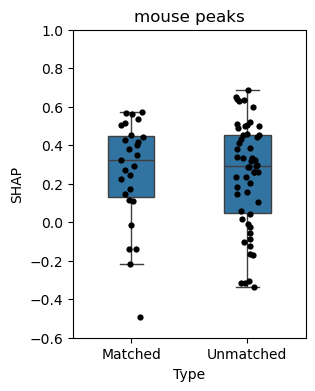

In [120]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# combine arr2 and arr3
arr1 = np.concatenate([mouse_fbpeak_zebra_fb_SHAP_corr, mouse_hbpeak_zebra_hb_SHAP_corr, mouse_sppeak_zebra_sp_SHAP_corr])
arr23 = np.concatenate([mouse_fbpeak_zebra_hb_SHAP_corr, mouse_fbpeak_zebra_sp_SHAP_corr,
                        mouse_hbpeak_zebra_fb_SHAP_corr, mouse_hbpeak_zebra_sp_SHAP_corr,
                        mouse_sppeak_zebra_fb_SHAP_corr,mouse_sppeak_zebra_hb_SHAP_corr])

# dataframe for plotting
df = pd.DataFrame({
    "SHAP": np.concatenate([arr1, arr23]),
    "type": ["Matched"]*len(arr1) + ["Unmatched"]*len(arr23)
})

plt.figure(figsize=(3,4))

# boxplot
sns.boxplot(data=df, x="type", y="SHAP", width=0.4,    showfliers=False)

# all points
sns.stripplot(
    data=df,
    x="type",
    y="SHAP",
    color="black",
    size=4.5,
    jitter=True
)

plt.title("mouse peaks")
plt.ylabel("SHAP")
plt.xlabel("Type")
plt.ylim([-0.6,1])
plt.savefig("mousepeaks_matched_unmatched_region_correlation_boxplot.svg")

plt.show()

### Zebrafish

In [110]:
zebra_forebrain_peaks= ['NC_007124.7:19328697-19329128',
                        'NC_007136.7:14994767-14995578',
                        'NC_007134.7:38413162-38414087',
                        'NC_007128.7:24287391-24288200',
                        'NC_007115.7:17200871-17201816',
                        'NC_007116.7:35090457-35091100',
                        'NC_007114.7:43319310-43320000',
                        'NC_007124.7:19516814-19517344',
                        'NC_007131.7:22502607-22503151',
                        'NC_007136.7:14993542-14994446',
                        'NC_007118.7:15925112-15925630',
                        'NC_007129.7:20130535-20131252',
                        'NC_007124.7:49454777-49455396',
                        'NC_007131.7:32455117-32456352',
                        'NC_007115.7:12533813-12534735',
                        'NC_007128.7:24287391-24288200',
                        'NC_007123.7:25568265-25568896',
                        'NC_007112.7:7763429-7764360',
                        'NC_007133.7:23307953-23308826']

zebra_hindbrain_peaks = ['NC_007135.7:13175565-13175956',
                         'NC_007128.7:41504927-41505341',
                         'NC_007124.7:1260452-1260993']

zebra_spinal_peaks = ['NC_007124.7:17294721-17295547',
                      'NC_007128.7:52908902-52909250',
                      'NC_007120.7:1944676-1945000',
                      'NC_007134.7:36133953-36134923',
                      'NC_007122.7:18638438-18638871',
                      'NC_007117.7:43873172-43873575']

In [113]:
zebra_forebrain_df = zebrafish_final_peaks[zebrafish_final_peaks.mouse_chr.isin(zebra_forebrain_peaks)]
zebra_hindbrain_df = zebrafish_final_peaks[zebrafish_final_peaks.mouse_chr.isin(zebra_hindbrain_peaks)]
zebra_spinal_df = zebrafish_final_peaks[zebrafish_final_peaks.mouse_chr.isin(zebra_spinal_peaks)]

In [115]:
zebra_forebrain_seq, zebra_forebrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_forebrain_df)
zebra_hindbrain_seq, zebra_hindbrain_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_hindbrain_df)
zebra_spinal_seq, zebra_spinal_onehot_seq = generate_onehot_sequences('../../mouse_zebrafish/zebrafish/model/GCF_000002035.6_GRCz11_genomic.fa',zebra_spinal_df)

(18, 2114, 4)
(3, 2114, 4)
(6, 2114, 4)


In [116]:
# forebrain 
zebra_fbpeak_zebra_fbmodel_SHAP = compute_and_save_shap_scores(zebra_forebrain, zebra_forebrain_onehot_seq)
zebra_fbpeak_mouse_fbmodel_SHAP = compute_and_save_shap_scores(mouse_forebrain, zebra_forebrain_onehot_seq)
zebra_fbpeak_mouse_hbmodel_SHAP = compute_and_save_shap_scores(mouse_hindbrain, zebra_forebrain_onehot_seq)
zebra_fbpeak_mouse_spmodel_SHAP = compute_and_save_shap_scores(mouse_spinal, zebra_forebrain_onehot_seq)

# hindbrain 
zebra_hbpeak_zebra_hbmodel_SHAP = compute_and_save_shap_scores(zebra_hindbrain, zebra_hindbrain_onehot_seq)
zebra_hbpeak_mouse_fbmodel_SHAP = compute_and_save_shap_scores(mouse_forebrain, zebra_hindbrain_onehot_seq)
zebra_hbpeak_mouse_hbmodel_SHAP = compute_and_save_shap_scores(mouse_hindbrain, zebra_hindbrain_onehot_seq)
zebra_hbpeak_mouse_spmodel_SHAP = compute_and_save_shap_scores(mouse_spinal, zebra_hindbrain_onehot_seq)

# spinal cord 
zebra_sppeak_zebra_spmodel_SHAP = compute_and_save_shap_scores(zebra_spinal, zebra_spinal_onehot_seq)
zebra_sppeak_mouse_fbmodel_SHAP = compute_and_save_shap_scores(mouse_forebrain, zebra_spinal_onehot_seq)
zebra_sppeak_mouse_hbmodel_SHAP = compute_and_save_shap_scores(mouse_hindbrain, zebra_spinal_onehot_seq)
zebra_sppeak_mouse_spmodel_SHAP = compute_and_save_shap_scores(mouse_spinal, zebra_spinal_onehot_seq)


Done 0 examples of 18
(18, 2114, 4) (18, 2114, 4)
Done 0 examples of 18
(18, 2114, 4) (18, 2114, 4)
Done 0 examples of 18
(18, 2114, 4) (18, 2114, 4)
Done 0 examples of 18
(18, 2114, 4) (18, 2114, 4)
Done 0 examples of 3
(3, 2114, 4) (3, 2114, 4)
Done 0 examples of 3
(3, 2114, 4) (3, 2114, 4)
Done 0 examples of 3
(3, 2114, 4) (3, 2114, 4)
Done 0 examples of 3
(3, 2114, 4) (3, 2114, 4)
Done 0 examples of 6
(6, 2114, 4) (6, 2114, 4)
Done 0 examples of 6
(6, 2114, 4) (6, 2114, 4)
Done 0 examples of 6
(6, 2114, 4) (6, 2114, 4)
Done 0 examples of 6
(6, 2114, 4) (6, 2114, 4)


In [117]:
# forebrain
zebra_fbpeak_mouse_fb_SHAP_corr = calculate_correlations_subset(zebra_fbpeak_zebra_fbmodel_SHAP, zebra_fbpeak_mouse_fbmodel_SHAP, zebra_forebrain_df )
zebra_fbpeak_mouse_hb_SHAP_corr = calculate_correlations_subset(zebra_fbpeak_zebra_fbmodel_SHAP, zebra_fbpeak_mouse_hbmodel_SHAP, zebra_forebrain_df )
zebra_fbpeak_mouse_sp_SHAP_corr = calculate_correlations_subset(zebra_fbpeak_zebra_fbmodel_SHAP, zebra_fbpeak_mouse_spmodel_SHAP, zebra_forebrain_df )

# hindbrain
zebra_hbpeak_mouse_fb_SHAP_corr = calculate_correlations_subset(zebra_hbpeak_zebra_hbmodel_SHAP, zebra_hbpeak_mouse_fbmodel_SHAP, zebra_hindbrain_df )
zebra_hbpeak_mouse_hb_SHAP_corr = calculate_correlations_subset(zebra_hbpeak_zebra_hbmodel_SHAP, zebra_hbpeak_mouse_hbmodel_SHAP, zebra_hindbrain_df )
zebra_hbpeak_mouse_sp_SHAP_corr = calculate_correlations_subset(zebra_hbpeak_zebra_hbmodel_SHAP, zebra_hbpeak_mouse_spmodel_SHAP, zebra_hindbrain_df )

# spinal cord 
zebra_sppeak_mouse_fb_SHAP_corr = calculate_correlations_subset(zebra_sppeak_zebra_spmodel_SHAP, zebra_sppeak_mouse_fbmodel_SHAP, zebra_spinal_df )
zebra_sppeak_mouse_hb_SHAP_corr = calculate_correlations_subset(zebra_sppeak_zebra_spmodel_SHAP, zebra_sppeak_mouse_hbmodel_SHAP, zebra_spinal_df )
zebra_sppeak_mouse_sp_SHAP_corr = calculate_correlations_subset(zebra_sppeak_zebra_spmodel_SHAP, zebra_sppeak_mouse_spmodel_SHAP, zebra_spinal_df )

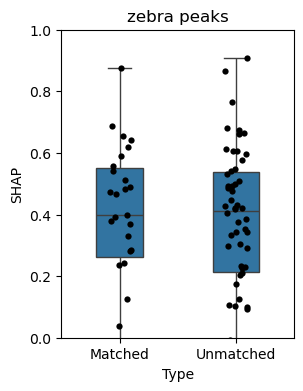

In [119]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# combine arr2 and arr3
arr1 = np.concatenate([zebra_fbpeak_mouse_fb_SHAP_corr, zebra_hbpeak_mouse_hb_SHAP_corr, zebra_sppeak_mouse_sp_SHAP_corr])
arr23 = np.concatenate([zebra_fbpeak_mouse_hb_SHAP_corr, zebra_fbpeak_mouse_sp_SHAP_corr,
                        zebra_hbpeak_mouse_fb_SHAP_corr, zebra_hbpeak_mouse_sp_SHAP_corr,
                        zebra_sppeak_mouse_fb_SHAP_corr, zebra_sppeak_mouse_hb_SHAP_corr])

# dataframe for plotting
df = pd.DataFrame({
    "SHAP": np.concatenate([arr1, arr23]),
    "type": ["Matched"]*len(arr1) + ["Unmatched"]*len(arr23)
})

plt.figure(figsize=(3,4))

# boxplot
sns.boxplot(data=df, x="type", y="SHAP", width=0.4,    showfliers=False)

# all points
sns.stripplot(
    data=df,
    x="type",
    y="SHAP",
    color="black",
    size=4.5,
    jitter=True
)

plt.title("zebra peaks")
plt.ylabel("SHAP")
plt.xlabel("Type")
plt.ylim([-0.,1])
plt.savefig("zebrapeaks_matched_unmatched_region_correlation_boxplot.svg")
plt.show()